In [ ]:
import os
import socket

# 1. Check the Hostname
print(f"Current Node: {socket.gethostname()}")

# 2. Check allocated CPUs (Slurm specific)
cpus = os.getenv('SLURM_CPUS_PER_TASK') or os.getenv('SLURM_JOB_CPUS_PER_NODE')
print(f"CPUs allocated by Slurm: {cpus}")

# 3. Check Job ID
job_id = os.getenv('SLURM_JOB_ID')
print(f"Slurm Job ID: {job_id}")

Current Node: gpu-sm01-01
CPUs allocated by Slurm: None
Slurm Job ID: 32722344


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import average_precision_score
from scipy import stats


In [ ]:
# ----- Edit these paths for your environment -----
# DATA_PATH: AnnData with log2(TMM-CPM+1) gene expression features.
# RESULT_DIR: where train_top_n_*.py scripts write their CSV outputs.
# WHOLE_GENOME_SCORES_PATH: scores from train_multiclass_rbf_svm.py (the whole-genome reference).
# BINARY_SCORES_PATH: scores from train_binary_rbf_svm.py (for the binary PR overlay).
DATA_PATH = "data/75k_unstable_anndata_log2tmmcpm_classification.h5ad"
RESULT_DIR = "results"
WHOLE_GENOME_SCORES_PATH = f"{RESULT_DIR}/multiclass_rbf_svm_scores.csv"
BINARY_SCORES_PATH = f"{RESULT_DIR}/binary_rbf_svm_scores.csv"
PLOT_DIR = "plots"

# Filename prefixes produced by the three top-N training scripts (their --metrics-prefix defaults)
SELECTED_PREFIX = "top_n_selected_genes"          # train_top_n_selected_rbf_svm.py
RANDOM_EXCLUDE_TOP50_PREFIX = "top_n_random_exclude_top50"  # train_top_n_random_exclude_top50_rbf_svm.py

import os
os.makedirs(PLOT_DIR, exist_ok=True)

In [ ]:
N_VALUES = [1, 3, 5, 10, 20, 50, 100, 200, 500]

def load_confusion(n):
    path = f"{RESULT_DIR}/{SELECTED_PREFIX}_rbf_n{n}_confusion_matrix.csv"
    return pd.read_csv(path, index_col=0)

def load_scores(n):
    path = f"{RESULT_DIR}/{SELECTED_PREFIX}_rbf_n{n}_scores.csv"
    return pd.read_csv(path)

In [ ]:
# Class counts from hard assignment (no_infection or max-count virus)
virus_counts_df = pd.read_csv(
    f"{RESULT_DIR}/virus_counts_df.csv",
    index_col=0,
)

counts_idx = virus_counts_df.index.to_series().astype(str).str.split("_", n=1).str[0]
virus_counts_df = virus_counts_df.copy()
virus_counts_df.index = counts_idx
virus_counts_df = virus_counts_df.groupby(virus_counts_df.index).sum()

row_totals = virus_counts_df.sum(axis=1)
labels = pd.Series("no_infection", index=virus_counts_df.index)
labels.loc[row_totals > 0] = virus_counts_df.loc[row_totals > 0].idxmax(axis=1)

labels.value_counts()

/tmp/ipykernel_2920221/2962897263.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = cm_pct.applymap(lambda v: f"{v:.1f}" if v > 0 else "")


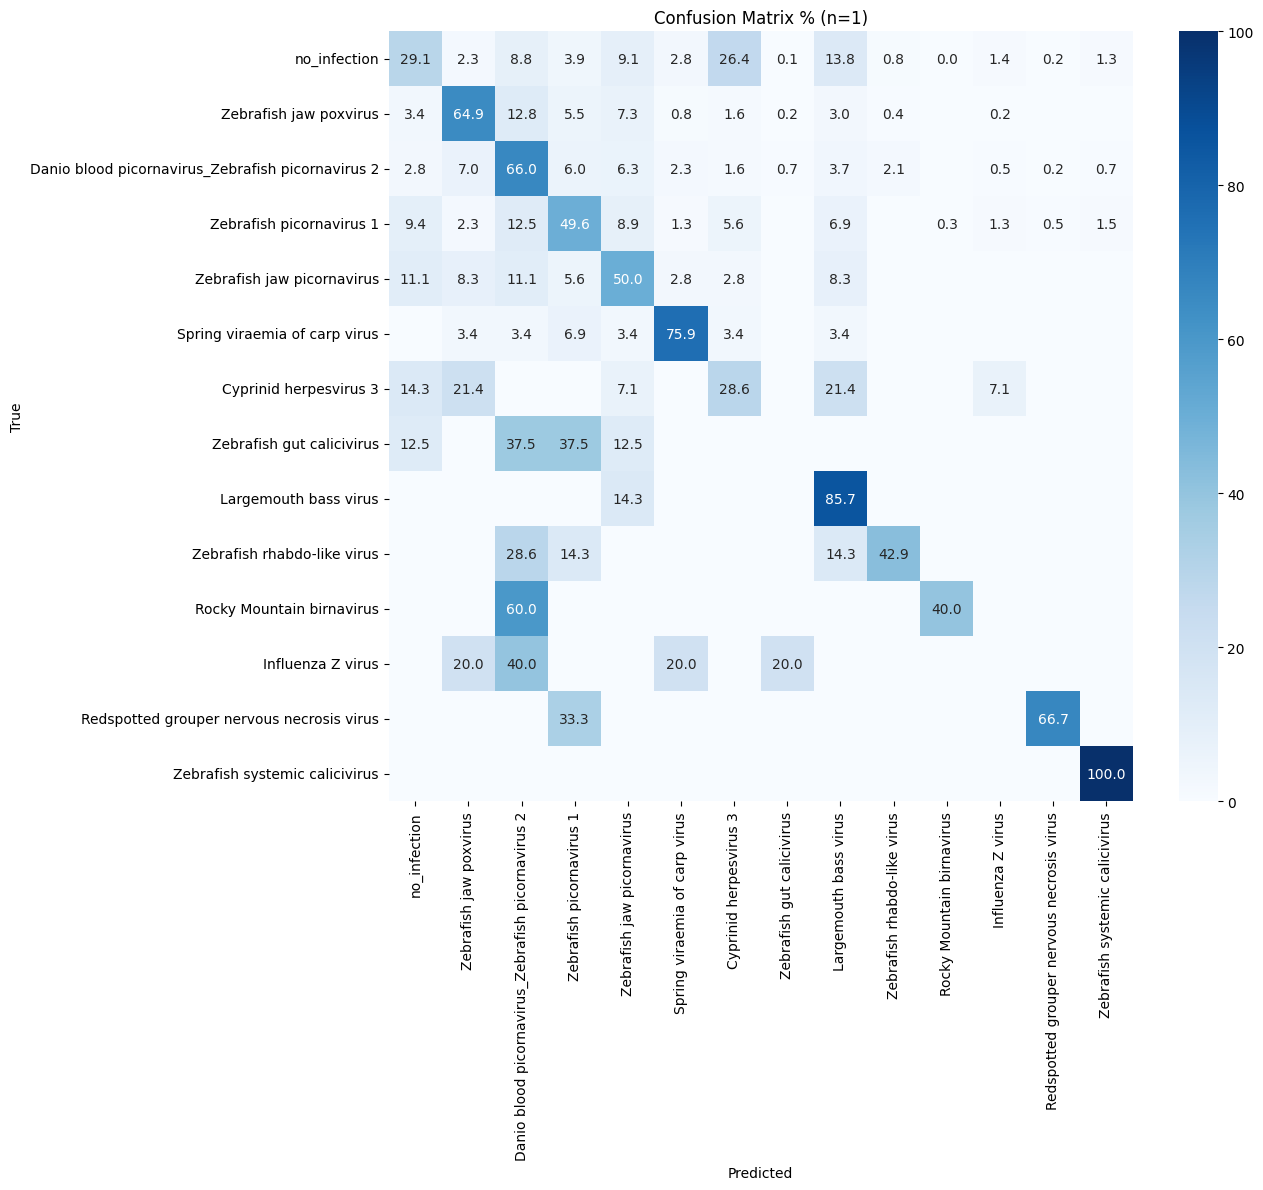

/tmp/ipykernel_2920221/2962897263.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = cm_pct.applymap(lambda v: f"{v:.1f}" if v > 0 else "")


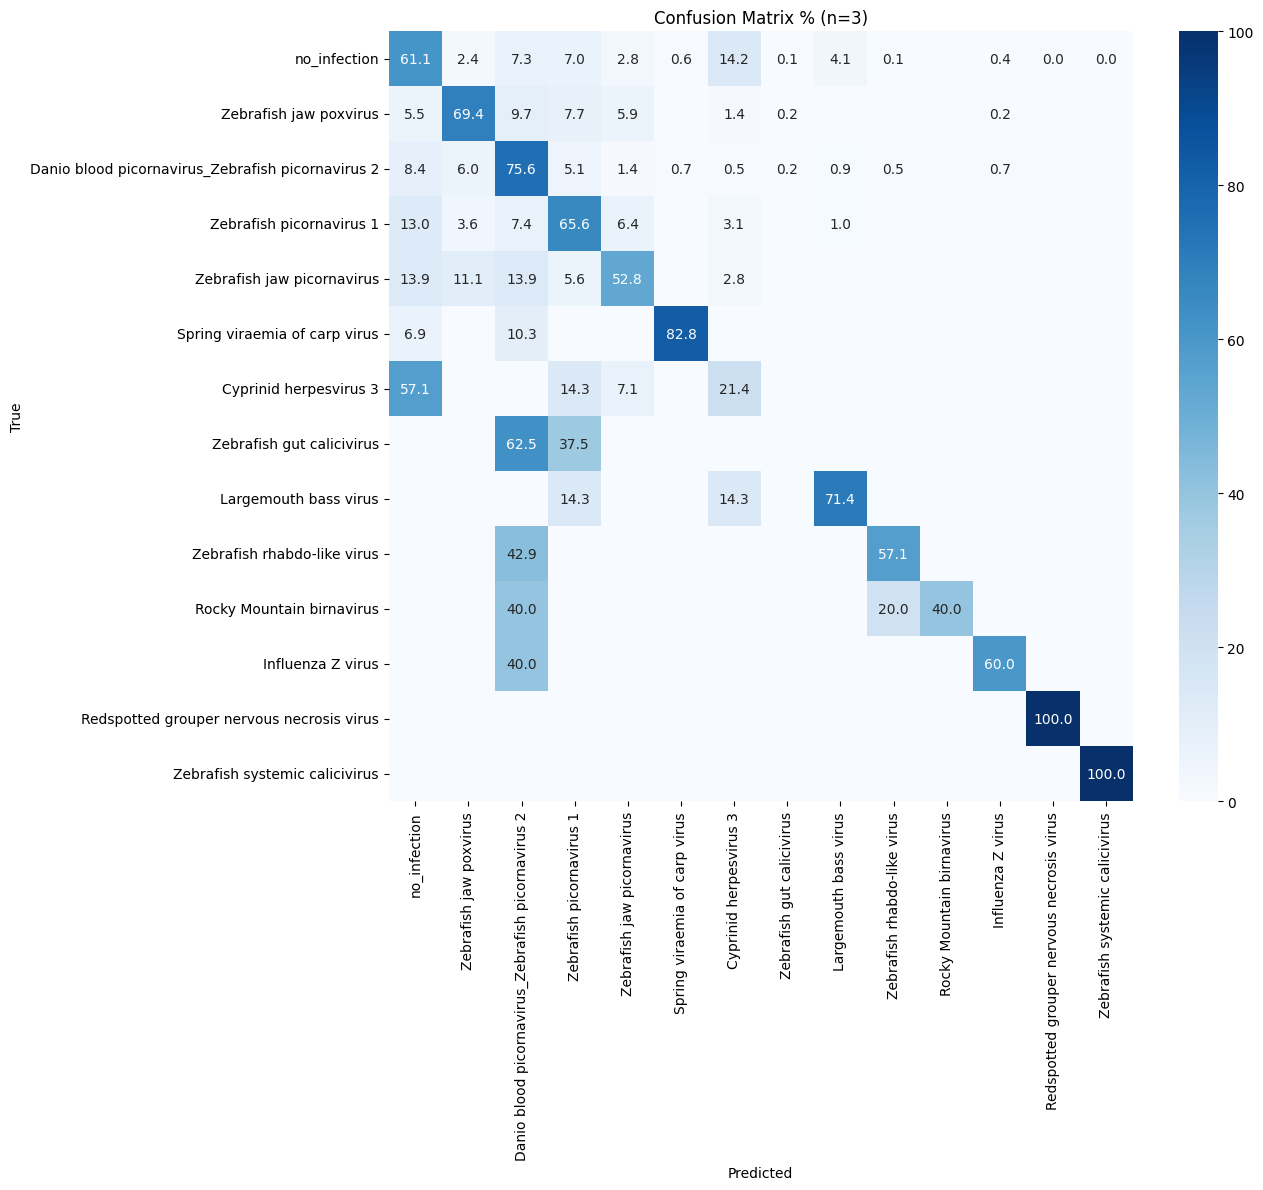

/tmp/ipykernel_2920221/2962897263.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = cm_pct.applymap(lambda v: f"{v:.1f}" if v > 0 else "")


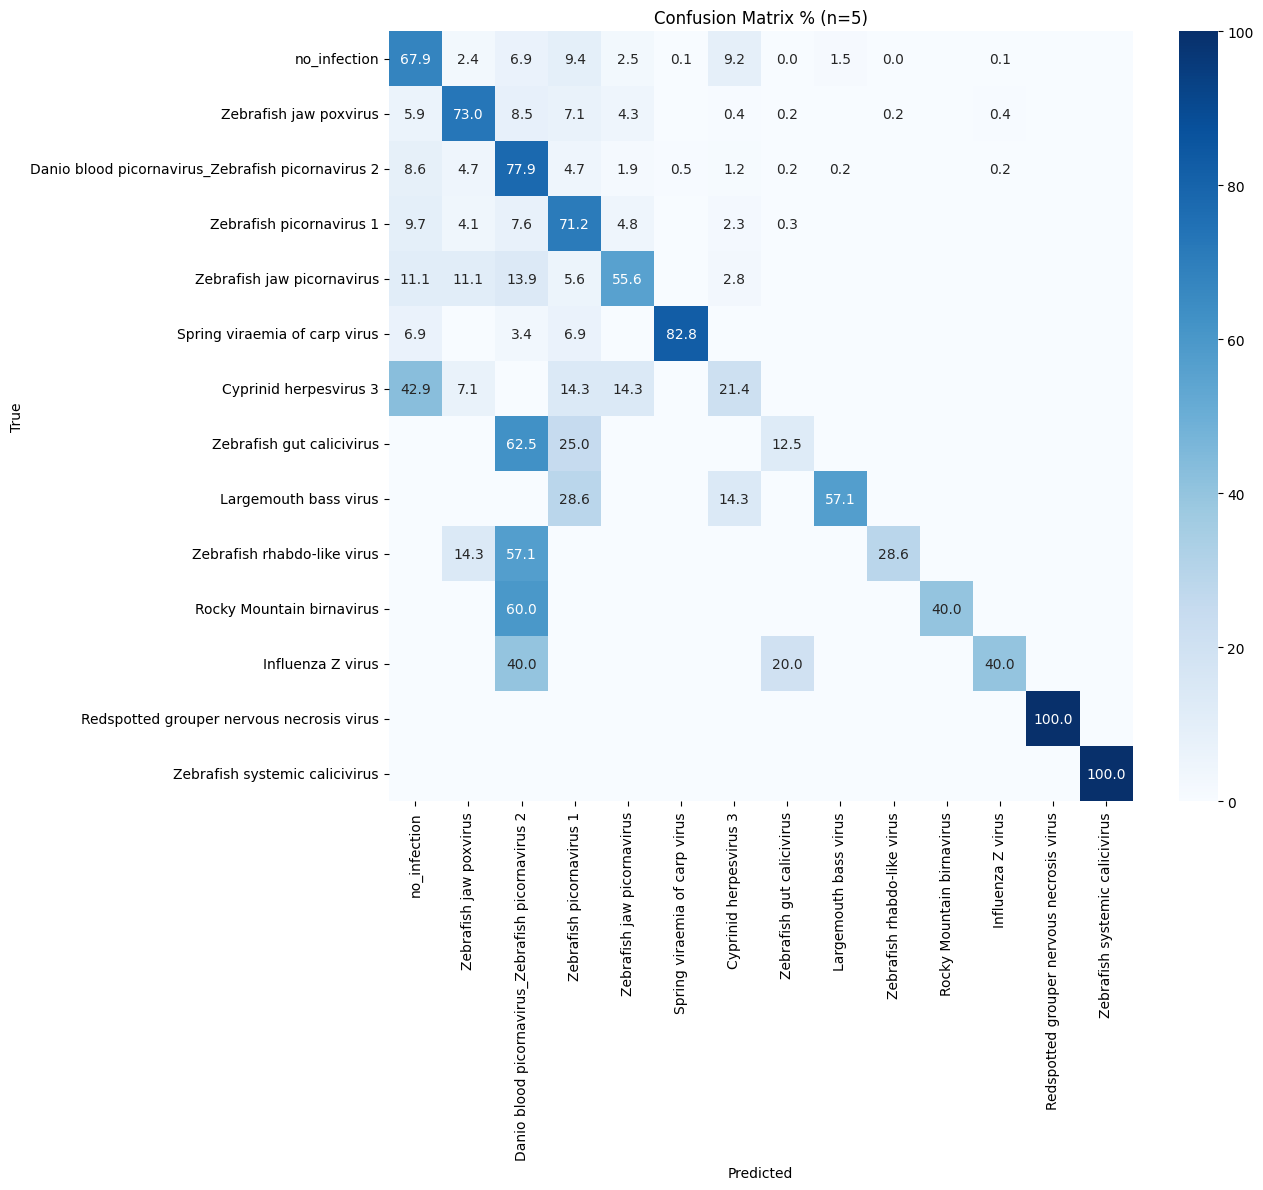

/tmp/ipykernel_2920221/2962897263.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = cm_pct.applymap(lambda v: f"{v:.1f}" if v > 0 else "")


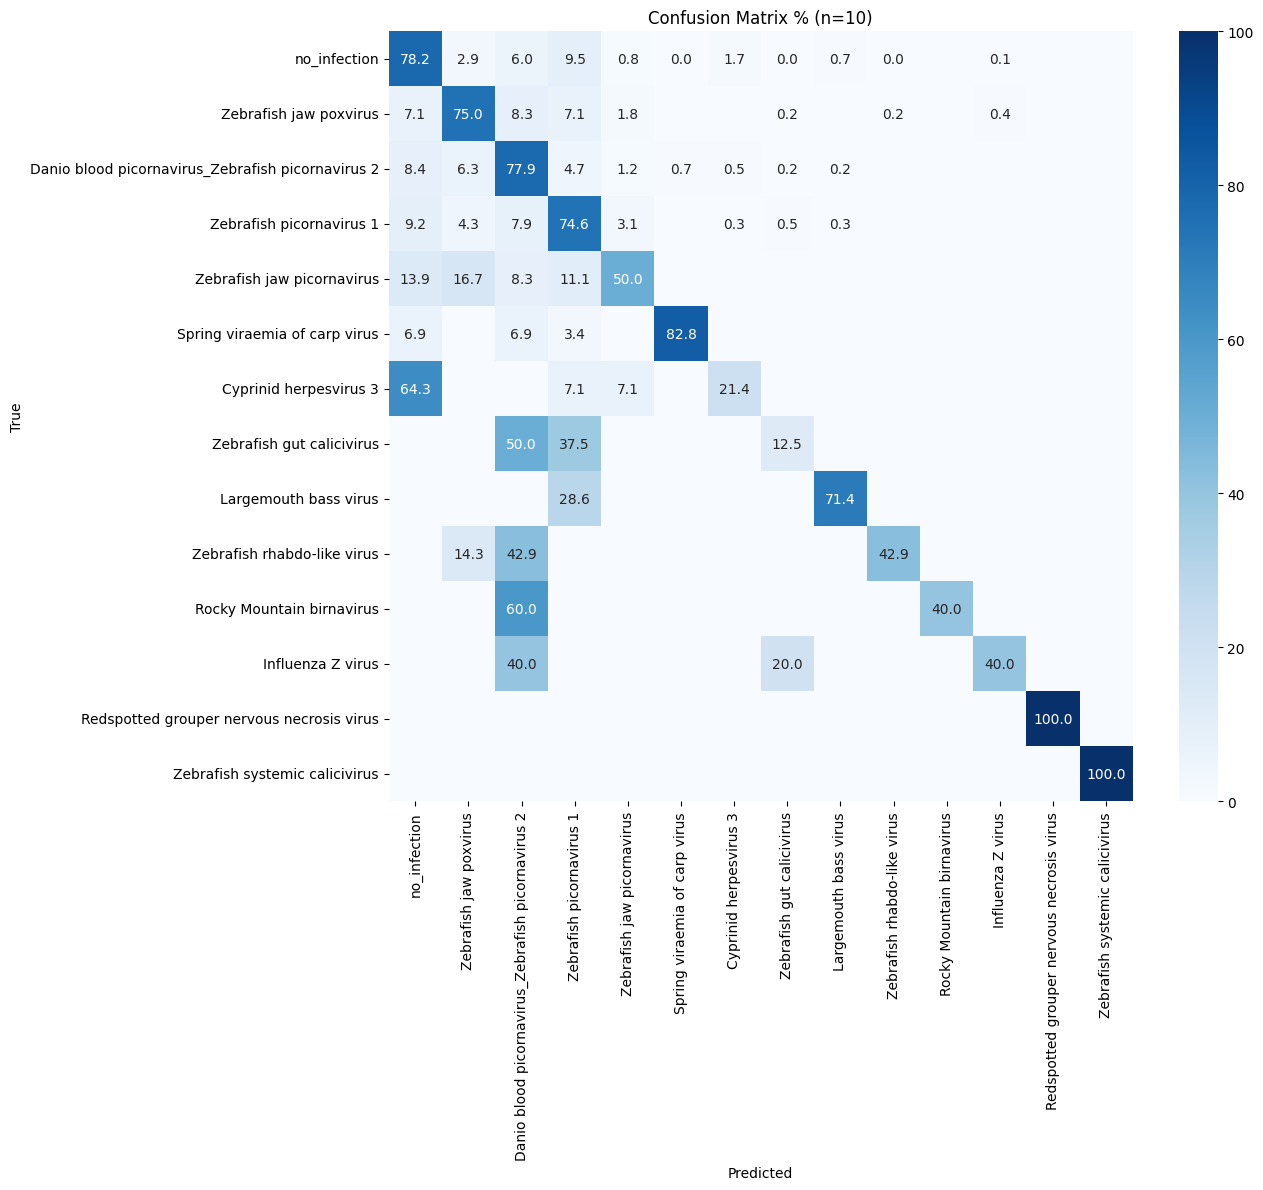

/tmp/ipykernel_2920221/2962897263.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = cm_pct.applymap(lambda v: f"{v:.1f}" if v > 0 else "")


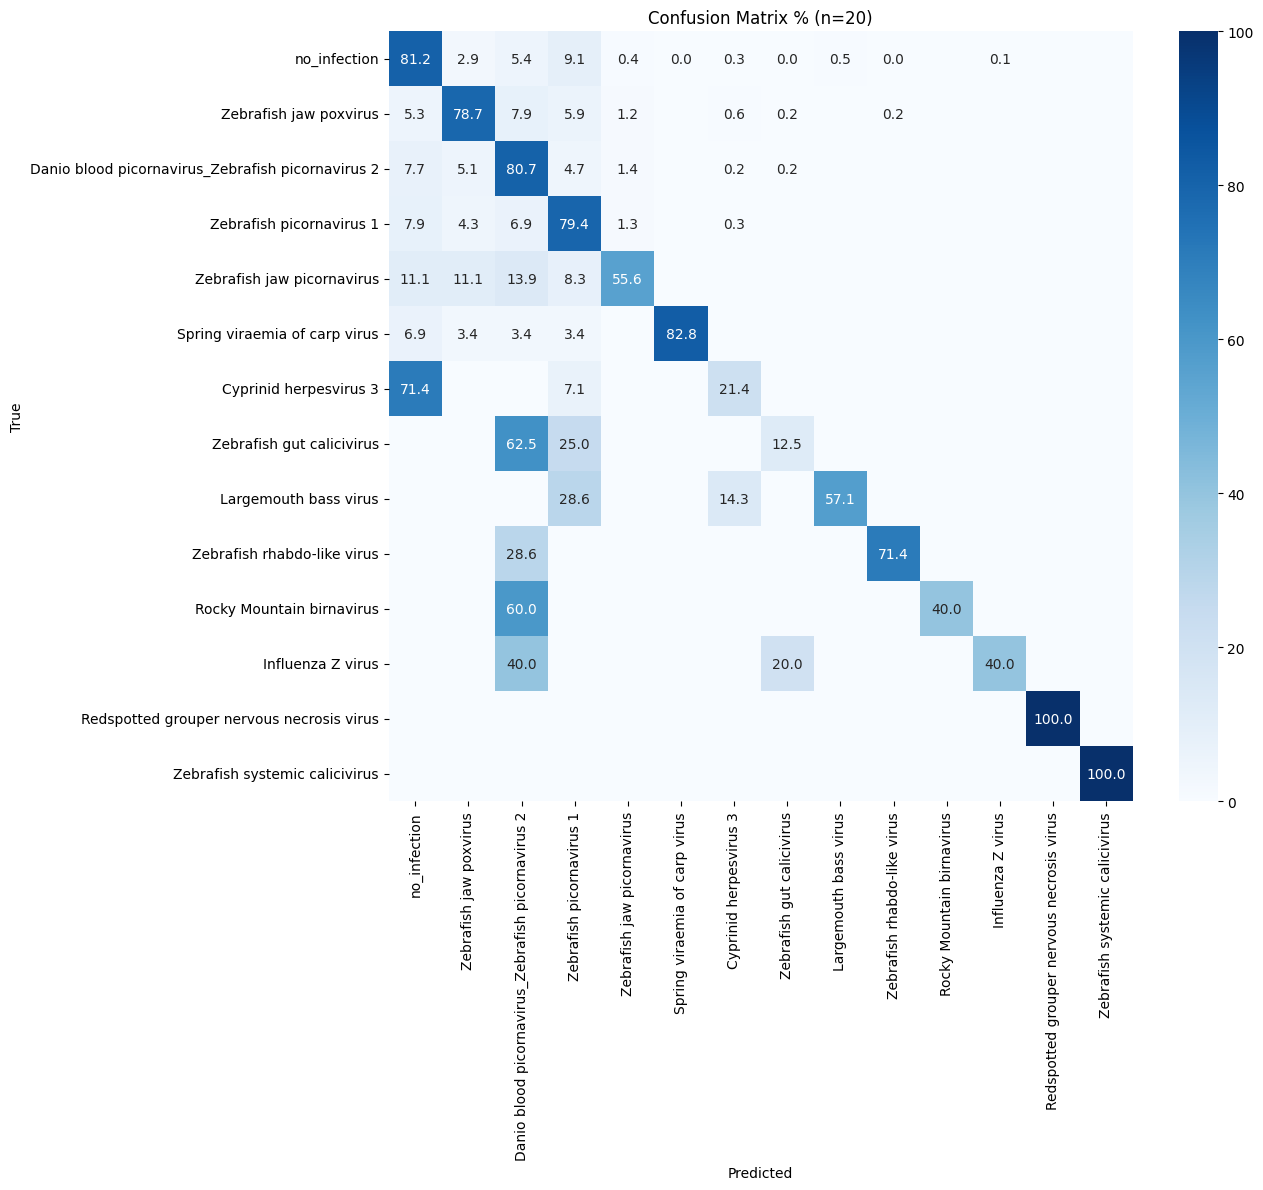

/tmp/ipykernel_2920221/2962897263.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = cm_pct.applymap(lambda v: f"{v:.1f}" if v > 0 else "")


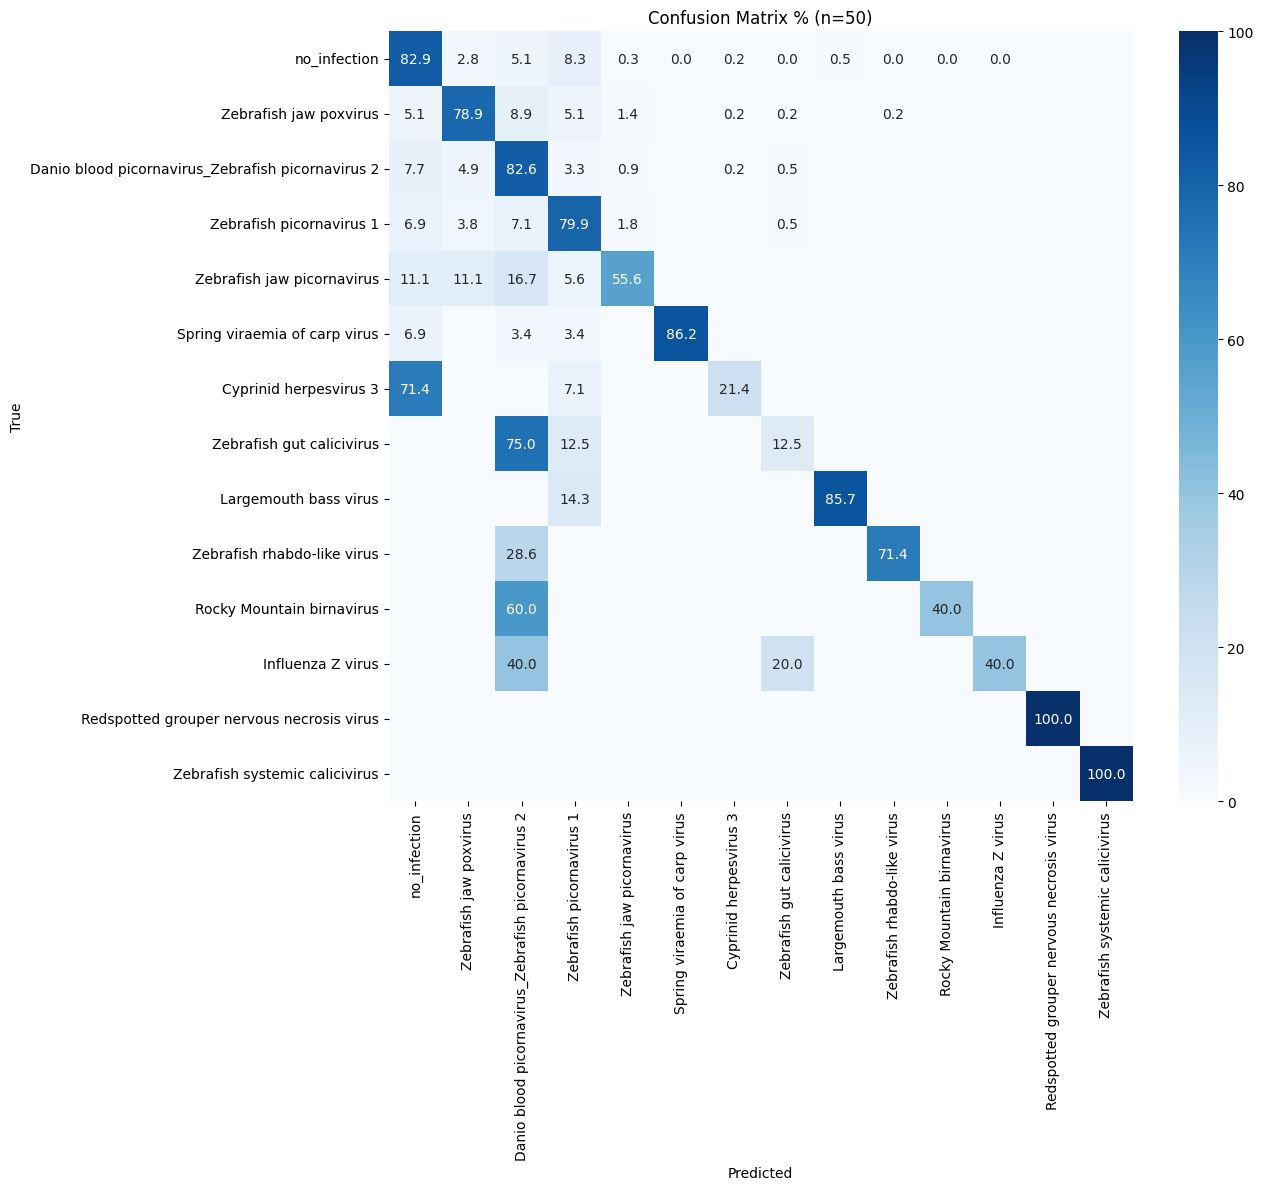

/tmp/ipykernel_2920221/2962897263.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = cm_pct.applymap(lambda v: f"{v:.1f}" if v > 0 else "")


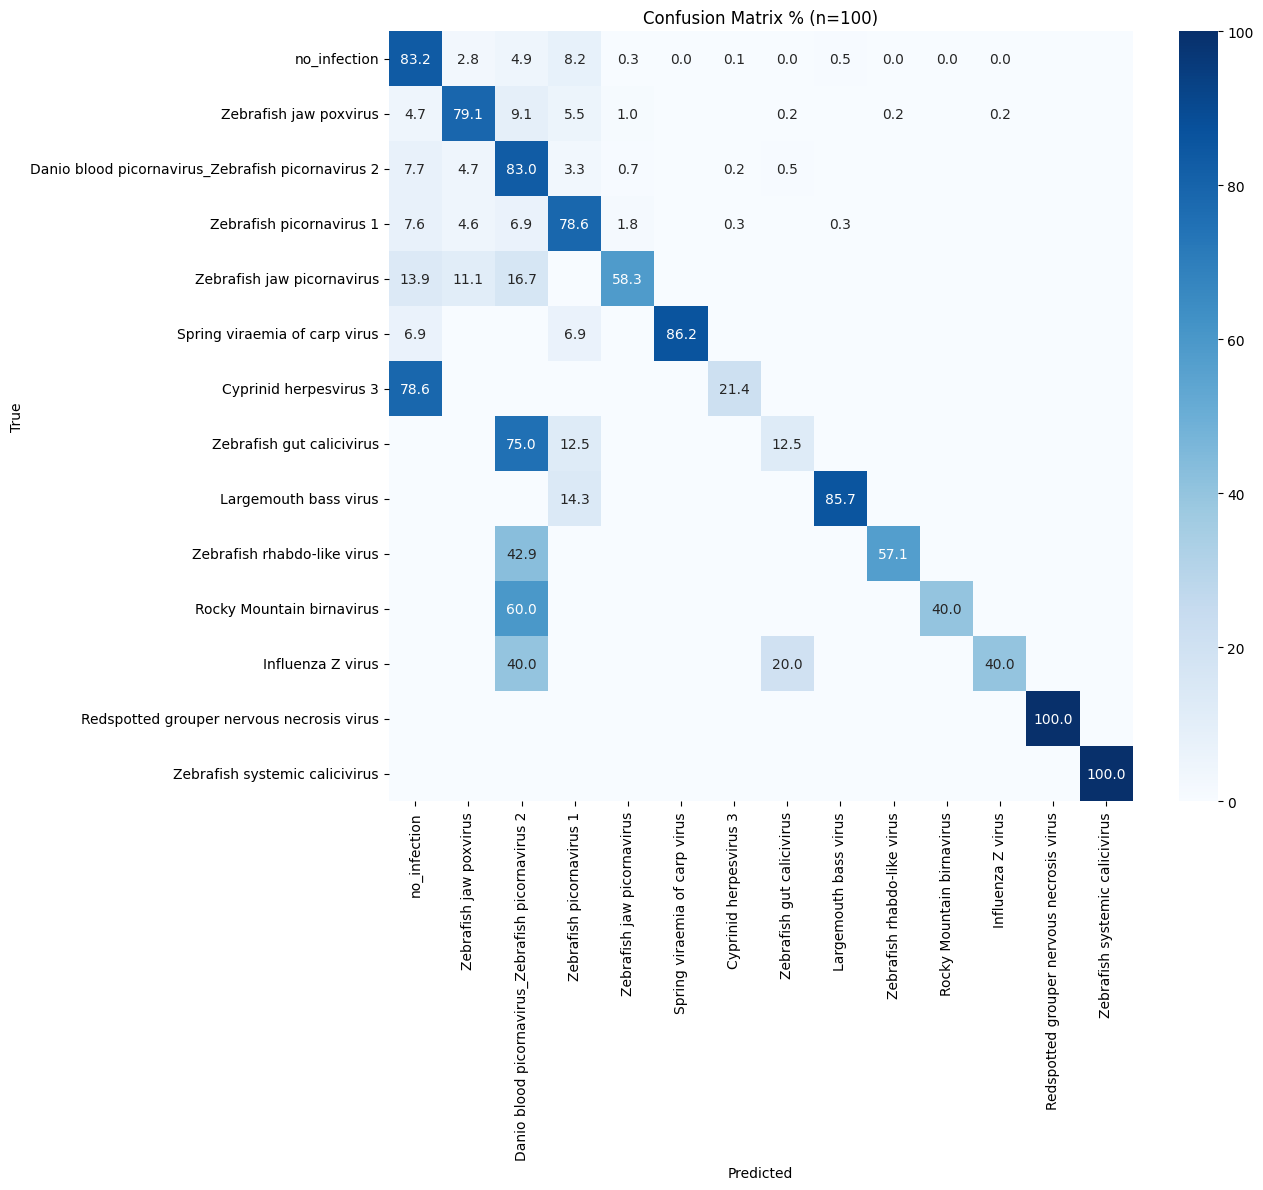

/tmp/ipykernel_2920221/2962897263.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = cm_pct.applymap(lambda v: f"{v:.1f}" if v > 0 else "")


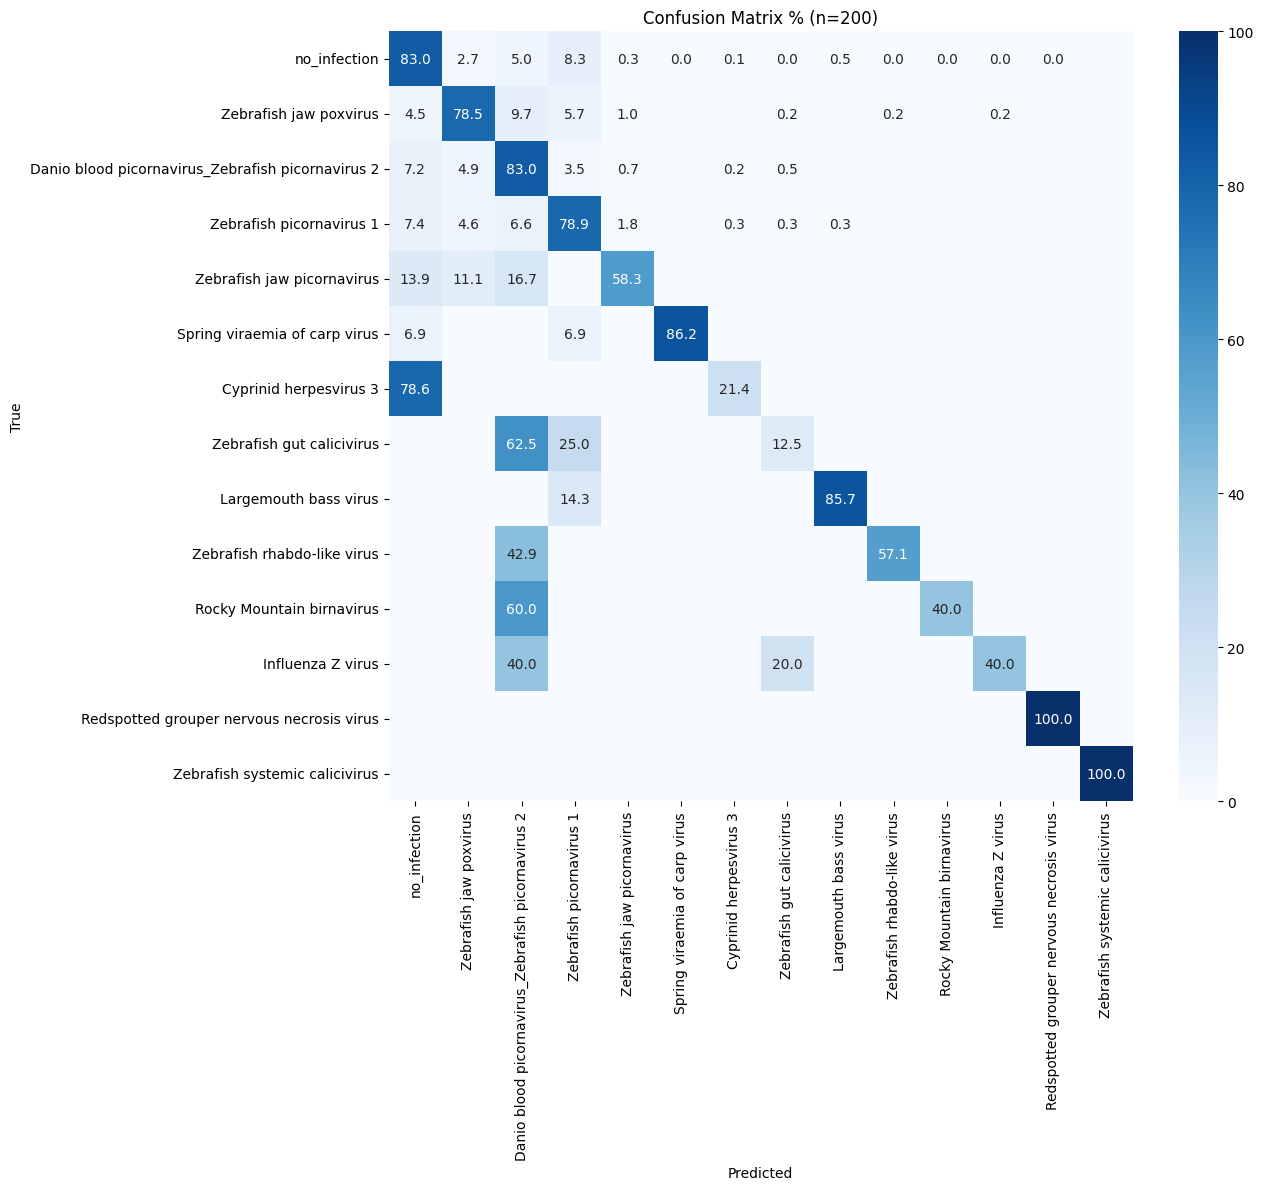

/tmp/ipykernel_2920221/2962897263.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = cm_pct.applymap(lambda v: f"{v:.1f}" if v > 0 else "")


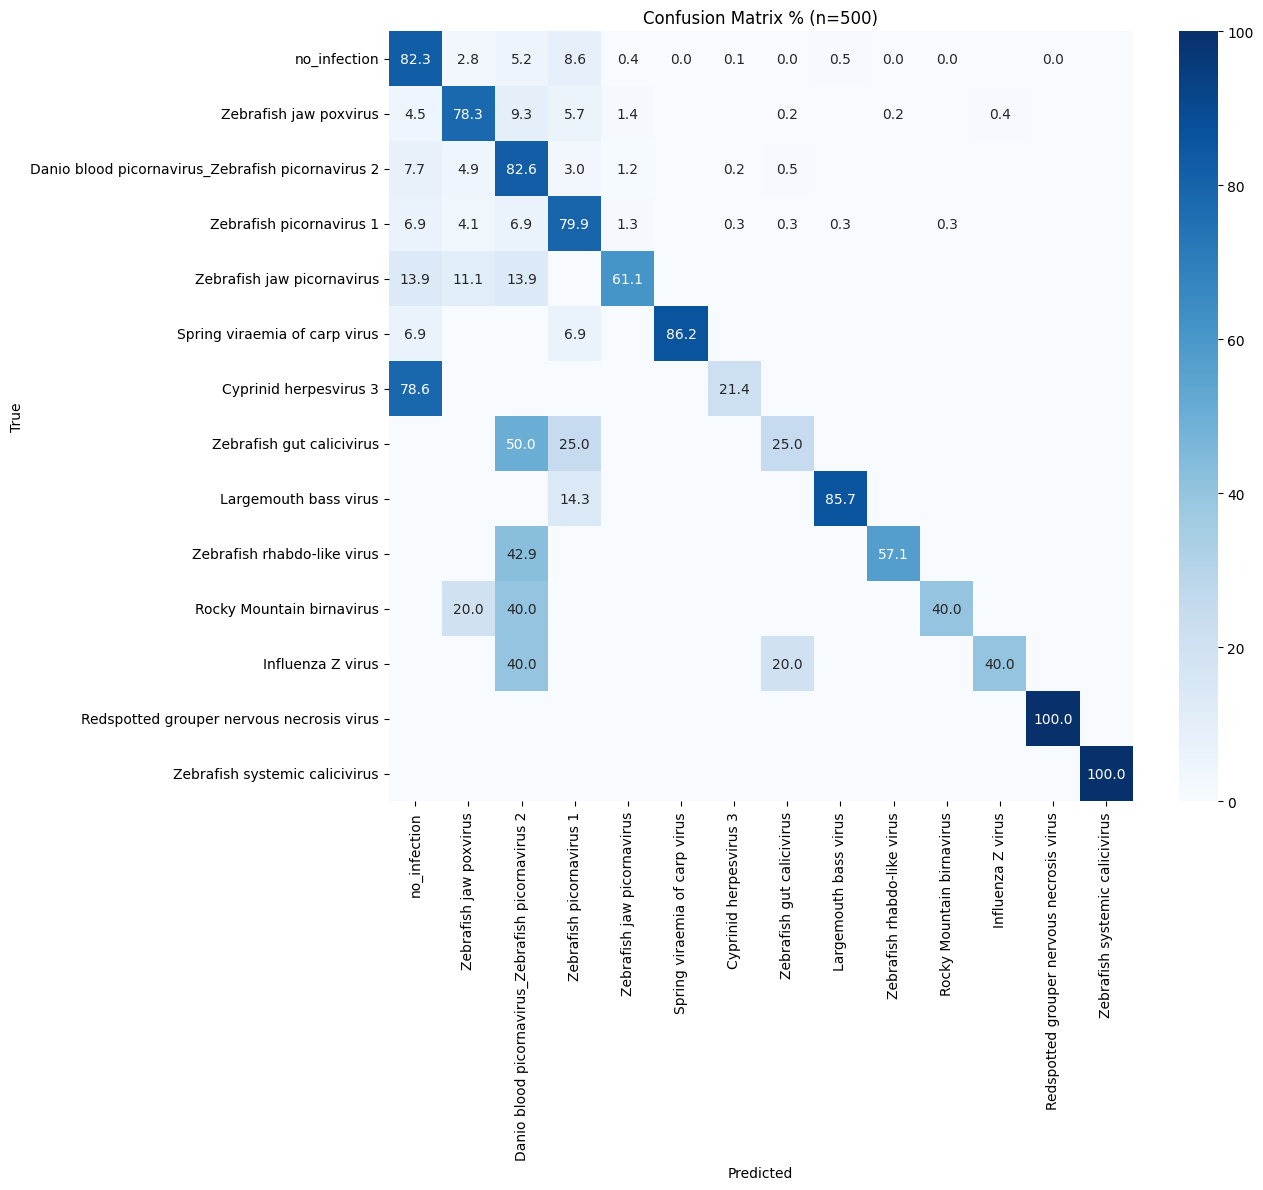

In [5]:

# Confusion matrices (all virus types) - row-normalized to 100%

for n in N_VALUES:
    cm_df = load_confusion(n)

    # Reorder rows/columns by label frequency in the scores file
    scores_df = load_scores(n)
    label_order = scores_df["y_true"].value_counts().index.tolist()
    cm_df = cm_df.reindex(index=label_order, columns=label_order)

    cm_pct = cm_df.div(cm_df.sum(axis=1), axis=0) * 100
    annot = cm_pct.applymap(lambda v: f"{v:.1f}" if v > 0 else "")

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_pct, cmap="Blues", cbar=True, annot=annot, fmt="")
    plt.title(f"Confusion Matrix % (n={n})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


In [ ]:
# AUPRC curves for top 5 classes (separate plots per N)
from sklearn.metrics import precision_recall_curve, average_precision_score

for n in N_VALUES:
    scores_df = load_scores(n)
    class_cols = [c for c in scores_df.columns if c not in ("y_true", "y_pred")]

    genes_path = (
        f"{RESULT_DIR}/{SELECTED_PREFIX}_n{n}_genes.csv"
    )
    try:
        genes_df = pd.read_csv(genes_path)
        print(f"n={n} genes used: {len(genes_df)}")
    except Exception as exc:
        print(f"n={n} genes file not found: {genes_path} ({exc})")

    counts = scores_df["y_true"].value_counts()
    top_classes = [c for c in counts.index if c != "no_infection"][:5]

    plt.figure(figsize=(6, 5))
    prevalences = []

    for cls in top_classes:
        if cls not in class_cols:
            continue
        y_true = (scores_df["y_true"] == cls).astype(int).to_numpy()
        y_score = scores_df[cls].to_numpy()
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        auprc = average_precision_score(y_true, y_score)
        prevalences.append(y_true.mean())
        plt.plot(recall, precision, label=f"{cls} (AUPRC={auprc:.2f})")

    # Baseline: max prevalence among selected classes (exclude no_infection)
    if prevalences:
        baseline = max(prevalences)
        plt.hlines(baseline, 0, 1, colors="gray", linestyles="--", label=f"baseline={baseline:.2f}")

    # Binary PR curve: use precomputed binary scores file
    binary_scores_path = BINARY_SCORES_PATH
    try:
        binary_df = pd.read_csv(binary_scores_path)
        b_y_true = (binary_df["y_true"] == "infected").astype(int)
        b_y_score = binary_df["p_infected"]
        precision_b, recall_b, _ = precision_recall_curve(b_y_true, b_y_score)
        auprc_b = average_precision_score(b_y_true, b_y_score)
        plt.plot(recall_b, precision_b, "k--", label=f"Binary (AUPRC={auprc_b:.2f})")
    except Exception:
        pass

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR curves (n={n})")
    plt.legend(fontsize=8)
    plt.show()

In [ ]:
# Confusion matrix + AUPRC for svm_gene_multiclass_hard_rbf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

result_dir = RESULT_DIR
cm_path = f"{RESULT_DIR}/multiclass_rbf_svm_confusion_matrix.csv"
scores_path = f"{RESULT_DIR}/multiclass_rbf_svm_scores.csv"

cm_df = pd.read_csv(cm_path, index_col=0)
scores_df = pd.read_csv(scores_path)

# Reorder rows/columns by label frequency in scores file
label_order = scores_df["y_true"].value_counts().index.tolist()
cm_df = cm_df.reindex(index=label_order, columns=label_order)

# Row-normalized confusion matrix (%)
cm_pct = cm_df.div(cm_df.sum(axis=1), axis=0) * 100
annot = cm_pct.applymap(lambda v: f"{v:.1f}" if v > 0 else "")

plt.figure(figsize=(12, 10))
sns.heatmap(cm_pct, cmap="Blues", cbar=True, annot=annot, fmt="")
plt.title("Confusion Matrix % (svm_gene_multiclass_hard_rbf)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# AUPRC curves for top 5 classes (exclude no_infection)
class_cols = [c for c in scores_df.columns if c not in ("y_true", "y_pred")]
counts = scores_df["y_true"].value_counts()
top_classes = [c for c in counts.index if c != "no_infection"][:5]

plt.figure(figsize=(6, 5))
prevalences = []

for cls in top_classes:
    if cls not in class_cols:
        continue
    y_true = (scores_df["y_true"] == cls).astype(int).to_numpy()
    y_score = scores_df[cls].to_numpy()
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    auprc = average_precision_score(y_true, y_score)
    prevalences.append(y_true.mean())
    plt.plot(recall, precision, label=f"{cls} (AUPRC={auprc:.2f})")

# Baseline: max prevalence among selected classes (exclude no_infection)
if prevalences:
    baseline = max(prevalences)
    plt.hlines(baseline, 0, 1, colors="gray", linestyles="--", label=f"baseline={baseline:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR curves (svm_gene_multiclass_hard_rbf)")
plt.legend(fontsize=8)
plt.show()

In [ ]:
# PR curves per virus: compare N values vs whole-genome RBF
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plot_dir = PLOT_DIR
os.makedirs(plot_dir, exist_ok=True)

# Load whole-genome RBF scores
whole_scores_path = (
    WHOLE_GENOME_SCORES_PATH
)
whole_df = pd.read_csv(whole_scores_path)

# Determine top-5 classes by frequency (exclude no_infection)
base_scores = load_scores(N_VALUES[0])
class_cols = [c for c in base_scores.columns if c not in ("y_true", "y_pred")]
counts = base_scores["y_true"].value_counts()
classes = [c for c in counts.index if c != "no_infection" and c in class_cols][:5]

colors = plt.cm.tab10.colors

for cls in classes:
    plt.figure(figsize=(6, 5))

    # Baseline prevalence for this virus (from base_scores)
    baseline = (base_scores["y_true"] == cls).astype(int).mean()
    plt.hlines(
        baseline,
        0,
        1,
        colors="gray",
        linestyles="--",
        label=f"baseline={baseline:.2f}",
    )

    # Plot each N as a different line
    for i, n in enumerate(N_VALUES):
        scores_df = load_scores(n)
        if cls not in scores_df.columns:
            continue
        y_true = (scores_df["y_true"] == cls).astype(int).to_numpy()
        y_score = pd.to_numeric(scores_df[cls], errors="coerce").to_numpy()
        mask = ~pd.isna(y_score)
        y_true = y_true[mask]
        y_score = y_score[mask]
        if len(y_true) == 0 or len(np.unique(y_true)) < 2:
            continue
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        auprc = average_precision_score(y_true, y_score)
        plt.plot(recall, precision, color=colors[i % len(colors)], label=f"n={n} (AUPRC={auprc:.2f})")

    # Whole-genome RBF line
    if cls in whole_df.columns:
        y_true_w = (whole_df["y_true"] == cls).astype(int).to_numpy()
        y_score_w = pd.to_numeric(whole_df[cls], errors="coerce").to_numpy()
        mask_w = ~pd.isna(y_score_w)
        y_true_w = y_true_w[mask_w]
        y_score_w = y_score_w[mask_w]
        if len(y_true_w) == 0 or len(np.unique(y_true_w)) < 2:
            plt.plot([], [], "k--", label="whole genome (AUPRC=NA)")
        else:
            precision_w, recall_w, _ = precision_recall_curve(y_true_w, y_score_w)
            auprc_w = average_precision_score(y_true_w, y_score_w)
            plt.plot(recall_w, precision_w, "k--", label=f"whole genome (AUPRC={auprc_w:.2f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR curves for {cls}")
    plt.legend(fontsize=8)
    safe_cls = cls.replace(" ", "_")
    out_path = os.path.join(plot_dir, f"pr_curves_per_virus_{safe_cls}.pdf")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

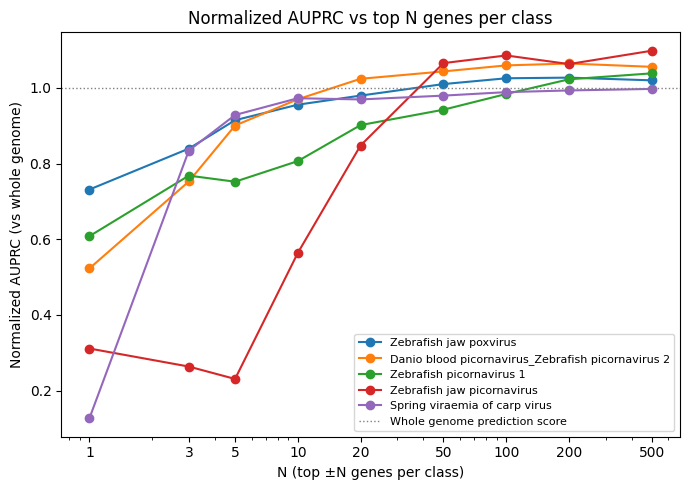

In [15]:
# Summary plot: normalized AUPRC vs N (per virus)
import numpy as np
from scipy import stats

# Compute whole-genome AUPRC per class
whole_auprc = {}
for cls in classes:
    if cls not in whole_df.columns:
        continue
    y_true_w = (whole_df["y_true"] == cls).astype(int).to_numpy()
    y_score_w = pd.to_numeric(whole_df[cls], errors="coerce").to_numpy()
    mask_w = ~pd.isna(y_score_w)
    y_true_w = y_true_w[mask_w]
    y_score_w = y_score_w[mask_w]
    if len(y_true_w) == 0 or len(np.unique(y_true_w)) < 2:
        continue
    whole_auprc[cls] = average_precision_score(y_true_w, y_score_w)

plt.figure(figsize=(7, 5))
colors = plt.cm.tab10.colors

for i, cls in enumerate(classes):
    if cls not in whole_auprc or whole_auprc[cls] <= 0:
        continue
    norm_scores = []
    for n in N_VALUES:
        scores_df = load_scores(n)
        if cls not in scores_df.columns:
            norm_scores.append(np.nan)
            continue
        y_true = (scores_df["y_true"] == cls).astype(int).to_numpy()
        y_score = pd.to_numeric(scores_df[cls], errors="coerce").to_numpy()
        mask = ~pd.isna(y_score)
        y_true = y_true[mask]
        y_score = y_score[mask]
        if len(y_true) == 0 or len(np.unique(y_true)) < 2: 
            norm_scores.append(np.nan)
            continue
        auprc = average_precision_score(y_true, y_score)
        norm_scores.append(auprc / whole_auprc[cls])

    plt.plot(N_VALUES, norm_scores, marker="o", color=colors[i % len(colors)], label=cls)

plt.xlabel("N (top ±N genes per class)")
plt.ylabel("Normalized AUPRC (vs whole genome)")
plt.title("Normalized AUPRC vs top N genes per class")
plt.xscale("log")
plt.xticks(N_VALUES, labels=[str(n) for n in N_VALUES])
plt.axhline(1.0, color="gray", linestyle=":", linewidth=1, label="Whole genome prediction score")
plt.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.savefig(f"{plot_dir}/svm_gene_selection_top.pdf", dpi=300)
plt.show()


In [ ]:
# Summary plot: normalized AUPRC vs N (per virus)
import numpy as np
from scipy import stats

# Compute whole-genome AUPRC per class
whole_auprc = {}
for cls in classes:
    if cls not in whole_df.columns:
        continue
    y_true_w = (whole_df["y_true"] == cls).astype(int).to_numpy()
    y_score_w = pd.to_numeric(whole_df[cls], errors="coerce").to_numpy()
    mask_w = ~pd.isna(y_score_w)
    y_true_w = y_true_w[mask_w]
    y_score_w = y_score_w[mask_w]
    if len(y_true_w) == 0 or len(np.unique(y_true_w)) < 2:
        continue
    whole_auprc[cls] = average_precision_score(y_true_w, y_score_w)

plt.figure(figsize=(7, 5))
colors = plt.cm.tab10.colors

for i, cls in enumerate(classes):
    if cls not in whole_auprc or whole_auprc[cls] <= 0:
        continue
    norm_scores = []
    for n in N_VALUES:
        scores_df = load_scores(n)
        if cls not in scores_df.columns:
            norm_scores.append(np.nan)
            continue
        y_true = (scores_df["y_true"] == cls).astype(int).to_numpy()
        y_score = pd.to_numeric(scores_df[cls], errors="coerce").to_numpy()
        mask = ~pd.isna(y_score)
        y_true = y_true[mask]
        y_score = y_score[mask]
        if len(y_true) == 0 or len(np.unique(y_true)) < 2:
            norm_scores.append(np.nan)
            continue
        auprc = average_precision_score(y_true, y_score)
        norm_scores.append(auprc / whole_auprc[cls])

    plt.plot(N_VALUES, norm_scores, marker="o", color=colors[i % len(colors)], label=cls)

# Overlay random-gene curves (dotted, thinner) from result_random_all
RESULT_DIR_RANDOM_EXCLUDE = RESULT_DIR
N_RANDOM = [1, 3, 5, 10, 20, 50, 100, 200, 500]
SEEDS_RANDOM = [42, 43, 44, 45, 46, 48, 49, 50, 51]

def _path_proba_random(n, seed):
    return f"{RESULT_DIR_RANDOM}/{RANDOM_EXCLUDE_TOP50_PREFIX}_random_shuffle_seed{seed}_n{n}_rbf_scores.csv"

def load_scores_per_seed_random(n):
    return [(s, pd.read_csv(_path_proba_random(n, s))) for s in SEEDS_RANDOM]

for i, cls in enumerate(classes):
    if cls not in whole_auprc or whole_auprc[cls] <= 0:
        continue
    means, sems = [], []
    for n in N_RANDOM:
        norm_auprcs = []
        for seed, scores_df in load_scores_per_seed_random(n):
            if cls not in scores_df.columns:
                continue
            y_true = (scores_df["y_true"] == cls).astype(int).to_numpy()
            y_score = pd.to_numeric(scores_df[cls], errors="coerce").to_numpy()
            mask = ~pd.isna(y_score)
            y_true, y_score = y_true[mask], y_score[mask]
            if len(y_true) == 0 or len(np.unique(y_true)) < 2:
                continue
            norm_auprcs.append(average_precision_score(y_true, y_score) / whole_auprc[cls])
        means.append(np.mean(norm_auprcs) if norm_auprcs else np.nan)
        sems.append(stats.sem(norm_auprcs) if len(norm_auprcs) > 1 else 0.0)
    means = np.array(means)
    sems = np.array(sems)
    valid = ~np.isnan(means)
    if not np.any(valid):
        continue
    x = np.array(N_RANDOM)[valid]
    y, err = means[valid], sems[valid]
    plt.errorbar(x, y, yerr=err, linestyle=":", linewidth=1, marker="o", markersize=3,
                 color=colors[i % len(colors)], capsize=2, capthick=0.8, label=f"{cls} (random)")

plt.xlabel("N (top ±N genes per class)")
plt.ylabel("Normalized AUPRC (vs whole genome)")
plt.title("Normalized AUPRC vs top N genes per class")
plt.xscale("log")
plt.xticks(N_VALUES, labels=[str(n) for n in N_VALUES])
plt.axhline(1.0, color="gray", linestyle=":", linewidth=1, label="Whole genome prediction score")
plt.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

In [ ]:
# Same style as above, but only: 5 random seeds + whole genome at 1.0 (no selection curves)
import numpy as np
from scipy import stats
from sklearn.metrics import average_precision_score

whole_auprc = {}
for cls in classes:
    if cls not in whole_df.columns:
        continue
    y_true_w = (whole_df["y_true"] == cls).astype(int).to_numpy()
    y_score_w = pd.to_numeric(whole_df[cls], errors="coerce").to_numpy()
    mask_w = ~pd.isna(y_score_w)
    y_true_w = y_true_w[mask_w]
    y_score_w = y_score_w[mask_w]
    if len(y_true_w) == 0 or len(np.unique(y_true_w)) < 2:
        continue
    whole_auprc[cls] = average_precision_score(y_true_w, y_score_w)

plt.figure(figsize=(7, 5))
colors = plt.cm.tab10.colors

RESULT_DIR_RANDOM_EXCLUDE = RESULT_DIR
N_VALUES = [1, 3, 5, 10, 20, 50, 100, 200, 500]
SEEDS_FIVE = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


def _path_proba_random(n, seed):
    return f"{RESULT_DIR_RANDOM}/{RANDOM_EXCLUDE_TOP50_PREFIX}_random_shuffle_seed{seed}_n{n}_rbf_scores.csv"


def load_scores_five_seeds_random(n):
    return [(s, pd.read_csv(_path_proba_random(n, s))) for s in SEEDS_FIVE]


for i, cls in enumerate(classes):
    if cls not in whole_auprc or whole_auprc[cls] <= 0:
        continue
    means, sems = [], []
    for n in N_VALUES:
        norm_auprcs = []
        for seed, scores_df in load_scores_five_seeds_random(n):
            if cls not in scores_df.columns:
                continue
            y_true = (scores_df["y_true"] == cls).astype(int).to_numpy()
            y_score = pd.to_numeric(scores_df[cls], errors="coerce").to_numpy()
            mask = ~pd.isna(y_score)
            y_true, y_score = y_true[mask], y_score[mask]
            if len(y_true) == 0 or len(np.unique(y_true)) < 2:
                continue
            norm_auprcs.append(
                average_precision_score(y_true, y_score) / whole_auprc[cls]
            )
        means.append(np.mean(norm_auprcs) if norm_auprcs else np.nan)
        sems.append(stats.sem(norm_auprcs) if len(norm_auprcs) > 1 else 0.0)
    means = np.array(means)
    sems = np.array(sems)
    valid = ~np.isnan(means)
    if not np.any(valid):
        continue
    x = np.array(N_VALUES)[valid]
    y, err = means[valid], sems[valid]
    plt.errorbar(
        x,
        y,
        yerr=err,
        linestyle=":",
        linewidth=1,
        marker="o",
        markersize=3,
        color=colors[i % len(colors)],
        capsize=2,
        capthick=0.8,
        label=f"{cls} (random, 10 seeds)",
    )

plt.xlabel("N (top ±N genes per class)")
plt.ylabel("Normalized AUPRC (vs whole genome)")
plt.title("Random genes only: normalized AUPRC vs N (10 seeds)")
plt.xscale("log")
plt.xticks(N_VALUES, labels=[str(n) for n in N_VALUES])
plt.axhline(
    1.0,
    color="gray",
    linestyle=":",
    linewidth=1.5,
    label="Whole genome prediction score",
)
plt.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.savefig(f"{plot_dir}/svm_random_genes_10_seeds.pdf", dpi=300)
plt.show()